In [1]:
!nvidia-smi
!nvcc --version

Sun Apr 26 08:25:19 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   61C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [5]:
import cupy as cp
import numpy as np
import time
import matplotlib.pyplot as plt
import pandas as pd

# --- KERNEL DEFINITIONS ---
kernel_code = r'''
extern "C" {
    // Basic Vector Addition
    __global__ void vectorAdd(const float* A, const float* B, float* C, int N) {
        int i = blockDim.x * blockIdx.x + threadIdx.x;
        if (i < N) C[i] = A[i] + B[i];
    }

    // Part C: Artificial Warp Divergence
    __global__ void divergentKernel(float* data, int N) {
        int i = blockDim.x * blockIdx.x + threadIdx.x;
        if (i < N) {
            if (i % 2 == 0) { data[i] *= 2.0f; }
            else { data[i] += 1.0f; }
        }
    }

    // Part C: Branch-Free Equivalent
    __global__ void branchFreeKernel(float* data, int N) {
        int i = blockDim.x * blockIdx.x + threadIdx.x;
        if (i < N) {
            int is_even = (i % 2 == 0);
            data[i] = (is_even * (data[i] * 2.0f)) + ((1 - is_even) * (data[i] + 1.0f));
        }
    }
}
'''
module = cp.RawModule(code=kernel_code)
vector_add = module.get_function('vectorAdd')
div_kernel = module.get_function('divergentKernel')
bf_kernel = module.get_function('branchFreeKernel')

# --- PART A: Bandwidth & Speedup Analysis ---
print("Running Part A: Bandwidth & Speedup...")
n_values = [2**10, 2**14, 2**18, 2**22, 2**26]
results_a = []

for N in n_values:
    # Host data
    a_cpu = np.random.randn(N).astype(np.float32)
    b_cpu = np.random.randn(N).astype(np.float32)

    # 1. CPU Time
    start = time.perf_counter()
    c_cpu = a_cpu + b_cpu
    cpu_time = (time.perf_counter() - start) * 1000 # ms

    # 2. H2D Transfer
    start = time.perf_counter()
    a_gpu = cp.array(a_cpu)
    b_gpu = cp.array(b_cpu)
    cp.cuda.Stream.null.synchronize()
    h2d_time = (time.perf_counter() - start) * 1000 # ms

    # 3. GPU Compute
    threads_per_block = 256
    grid_size = (N + threads_per_block - 1) // threads_per_block
    c_gpu = cp.empty_like(a_gpu)

    start_evt = cp.cuda.Event(); end_evt = cp.cuda.Event()
    start_evt.record()
    vector_add((grid_size,), (threads_per_block,), (a_gpu, b_gpu, c_gpu, N))
    end_evt.record()
    end_evt.synchronize()
    gpu_compute_time = cp.cuda.get_elapsed_time(start_evt, end_evt) # ms

    speedup = cpu_time / (h2d_time + gpu_compute_time)
    results_a.append([N, cpu_time, gpu_compute_time, h2d_time, speedup])

df_a = pd.DataFrame(results_a, columns=['N', 'CPU(ms)', 'GPU_Comp(ms)', 'H2D(ms)', 'Speedup'])
print(df_a)

# --- PART B: Launch Configuration ---
print("\nRunning Part B: Launch Configuration...")
N_fixed = 2**20
block_sizes = [64, 128, 256, 512, 1024]
results_b = []

for bs in block_sizes:
    grid_size = (N_fixed + bs - 1) // bs
    start_evt.record()
    vector_add((grid_size,), (bs,), (a_gpu, b_gpu, c_gpu, N_fixed)) # reusing buffers
    end_evt.record()
    end_evt.synchronize()
    results_b.append([bs, grid_size, cp.cuda.get_elapsed_time(start_evt, end_evt)])

df_b = pd.DataFrame(results_b, columns=['BlockSize', 'GridSize', 'Time(ms)'])
print(df_b)

# --- PART C: Warp Divergence ---
print("\nRunning Part C: Warp Divergence Experiment...")
N_div = 2**22
data_gpu = cp.random.randn(N_div).astype(cp.float32)

# Divergent Test
start_evt.record()
div_kernel(((N_div+255)//256,), (256,), (data_gpu, N_div))
end_evt.record(); end_evt.synchronize()
t_div = cp.cuda.get_elapsed_time(start_evt, end_evt)

# Branch-Free Test
start_evt.record()
bf_kernel(((N_div+255)//256,), (256,), (data_gpu, N_div))
end_evt.record(); end_evt.synchronize()
t_bf = cp.cuda.get_elapsed_time(start_evt, end_evt)

print(f"Divergent Time: {t_div:.4f} ms")
print(f"Branch-Free Time: {t_bf:.4f} ms")
print(f"Divergence Penalty: {((t_div/t_bf)-1)*100:.2f}% slower")

Running Part A: Bandwidth & Speedup...
          N    CPU(ms)  GPU_Comp(ms)     H2D(ms)   Speedup
0      1024   0.653997      0.059744    0.883603  0.693273
1     16384   0.020478      1.564256    0.164073  0.011848
2    262144   0.256485      0.039200    0.707615  0.343438
3   4194304   5.184397      0.240000    8.006639  0.628668
4  67108864  98.086214      3.094464  120.947342  0.790751

Running Part B: Launch Configuration...
   BlockSize  GridSize  Time(ms)
0         64     16384  0.319168
1        128      8192  0.073952
2        256      4096  0.059360
3        512      2048  0.057792
4       1024      1024  0.058496

Running Part C: Warp Divergence Experiment...
Divergent Time: 0.1536 ms
Branch-Free Time: 0.2113 ms
Divergence Penalty: -27.31% slower


In [8]:
import cupy as cp
import numpy as np
import time

# --- KERNEL DEFINITIONS ---
reduction_code = r'''
extern "C" {
    // Part A: Shared Memory Tree Reduction (Max)
    __global__ void sharedMaxReduction(const float* input, float* output, int n) {
        // Dynamic shared memory allocation
        extern __shared__ float sdata[];

        unsigned int tid = threadIdx.x;
        unsigned int i = blockIdx.x * blockDim.x + threadIdx.x;

        // Load data into shared memory
        sdata[tid] = (i < n) ? input[i] : -1e38f; // Smallest float for max init
        __syncthreads();

        #include <cuda_runtime.h>

        // Tree reduction in shared memory
        for (unsigned int s = blockDim.x / 2; s > 0; s >>= 1) {
            if (tid < s) {
                if (sdata[tid + s] > sdata[tid]) {
                    sdata[tid] = sdata[tid + s];
                }
            }
            __syncthreads();
        }

        // Write result of this block to global memory
        if (tid == 0) output[blockIdx.x] = sdata[0];
    }

    // Part A: Warp Shuffle Reduction (using __shfl_down_sync)
    __global__ void warpShuffleReduction(const float* input, float* output, int n) {
        float val = (blockIdx.x * blockDim.x + threadIdx.x < n) ?
                     input[blockIdx.x * blockDim.x + threadIdx.x] : -1e38f;

        // Warp reduction using shuffle (no shared memory overhead)
        for (int offset = 16; offset > 0; offset /= 2) {
            float remote = __shfl_down_sync(0xFFFFFFFF, val, offset);
            if (remote > val) val = remote;
        }

        if ((threadIdx.x & 31) == 0) output[blockIdx.x / 32] = val;
    }

    // Part B: Bank Conflict Demo
    __global__ void bankConflictKernel(float* out, int stride) {
        __shared__ float shared_tile[1024];
        int tid = threadIdx.x;

        // Every thread accesses shared memory with a specific stride
        // Stride 1 = No conflict
        // Stride 32 = Maximum conflict (all threads hit Bank 0)
        shared_tile[tid * stride] = (float)tid;
        out[tid] = shared_tile[tid * stride];
    }
}
'''
module = cp.RawModule(code=reduction_code)
shared_red = module.get_function('sharedMaxReduction')
warp_red = module.get_function('warpShuffleReduction')
bank_kernel = module.get_function('bankConflictKernel')

# --- PART A: Three Reduction Strategies ---
N = 2**20
data_h = np.random.randn(N).astype(np.float32)
data_g = cp.array(data_h)

# 1. Naive Sequential (CPU Baseline)
start = time.perf_counter()
cpu_max = np.max(data_h)
t_cpu = (time.perf_counter() - start) * 1e6 # microseconds

# 2. Shared Memory Tree
threads = 256
blocks = (N + threads - 1) // threads
output_g = cp.zeros(blocks, dtype=cp.float32)

start_evt = cp.cuda.Event(); end_evt = cp.cuda.Event()
start_evt.record()
shared_red((blocks,), (threads,), (data_g, output_g, N), shared_mem=threads*4)
# Second pass to get final max from block results
final_max_shared = cp.max(output_g)
end_evt.record(); end_evt.synchronize()
t_shared = cp.cuda.get_elapsed_time(start_evt, end_evt) * 1000 # to microseconds

# 3. Warp Shuffle
start_evt.record()
warp_red(((N+31)//32,), (32,), (data_g, output_g, N))
final_max_warp = cp.max(output_g)
end_evt.record(); end_evt.synchronize()
t_warp = cp.cuda.get_elapsed_time(start_evt, end_evt) * 1000 # to microseconds

print(f"--- Reduction Results (N=2^20) ---")
print(f"Sequential CPU: {t_cpu:.2f} us")
print(f"Shared Memory:  {t_shared:.2f} us")
print(f"Warp Shuffle:   {t_warp:.2f} us")
print(f"Correctness Check: {np.allclose(cpu_max, final_max_warp, atol=0.1)}")

# --- PART B: Bank Conflict Profiling ---
print("\n--- Part B: Bank Conflict Analysis ---")
strides = [1, 2, 4, 8, 16, 32]
for s in strides:
    out = cp.zeros(1024, dtype=cp.float32)
    start_evt.record()
    bank_kernel((1,), (32,), (out, s)) # 1 warp to see pure conflict
    end_evt.record(); end_evt.synchronize()
    print(f"Stride {s}: {cp.cuda.get_elapsed_time(start_evt, end_evt)*1000:.4f} us")

--- Reduction Results (N=2^20) ---
Sequential CPU: 432.87 us
Shared Memory:  258.37 us
Warp Shuffle:   190.43 us
Correctness Check: False

--- Part B: Bank Conflict Analysis ---
Stride 1: 27.1360 us
Stride 2: 13.9840 us
Stride 4: 10.2400 us
Stride 8: 10.2080 us
Stride 16: 10.1440 us
Stride 32: 10.4640 us


In [9]:
import cupy as cp
import numpy as np
import time

# --- KERNEL DEFINITIONS ---
p2_extended_code = r'''
extern "C" {
    // Part B: 2D Shared Memory Padding (16x16 Tile)
    // No Padding: tile[16][16] -> Vertical access causes 16-way bank conflict
    // With Padding: tile[16][17] -> Vertical access is bank-conflict free
    __global__ void paddedTileKernel(float* out, int use_padding) {
        // We use 17 instead of 16 to shift the bank alignment
        __shared__ float tile_padded[16][17];
        __shared__ float tile_naive[16][16];

        int tx = threadIdx.x; // 0-15
        int ty = threadIdx.y; // 0-15

        if (use_padding) {
            tile_padded[ty][tx] = (float)(ty * 16 + tx);
            __syncthreads();
            // Read column-wise to stress the banks
            out[ty * 16 + tx] = tile_padded[tx][ty];
        } else {
            tile_naive[ty][tx] = (float)(ty * 16 + tx);
            __syncthreads();
            // Read column-wise
            out[ty * 16 + tx] = tile_naive[tx][ty];
        }
    }

    // Part C: Optimized Histogram using Shared Memory
    __global__ void sharedHistogram(const int* data, int* global_hist, int N, int num_bins) {
        // Private histogram in shared memory
        extern __shared__ int s_hist[];

        // Initialize shared hist to zero
        for (int i = threadIdx.x; i < num_bins; i += blockDim.x) {
            s_hist[i] = 0;
        }
        __syncthreads();

        // Global index
        int tid = blockIdx.x * blockDim.x + threadIdx.x;
        int stride = blockDim.x * gridDim.x;

        // Process data and update shared memory (less contention)
        for (int i = tid; i < N; i += stride) {
            int value = data[i];
            if (value >= 0 && value < num_bins) {
                atomicAdd(&s_hist[value], 1);
            }
        }
        __syncthreads();

        // Merge shared histogram into global memory
        for (int i = threadIdx.x; i < num_bins; i += blockDim.x) {
            atomicAdd(&global_hist[i], s_hist[i]);
        }
    }
}
'''
module_p2 = cp.RawModule(code=p2_extended_code)
tile_kernel = module_p2.get_function('paddedTileKernel')
hist_kernel = module_p2.get_function('sharedHistogram')

# --- PART B: Padding Speedup Test ---
print("--- Part B: Padding Solution ---")
out = cp.zeros(256, dtype=cp.float32)
start_evt = cp.cuda.Event(); end_evt = cp.cuda.Event()

# Test Naive (No Padding)
start_evt.record()
tile_kernel((1,), (16, 16), (out, 0))
end_evt.record(); end_evt.synchronize()
t_naive = cp.cuda.get_elapsed_time(start_evt, end_evt)

# Test Padded
start_evt.record()
tile_kernel((1,), (16, 16), (out, 1))
end_evt.record(); end_evt.synchronize()
t_padded = cp.cuda.get_elapsed_time(start_evt, end_evt)

print(f"Naive (16x16) Time:  {t_naive*1000:.4f} us")
print(f"Padded (16x17) Time: {t_padded*1000:.4f} us")
print(f"Speedup: {t_naive/t_padded:.2f}x")

# --- PART C: Shared Histogram ---
print("\n--- Part C: Shared Memory Histogram ---")
N_hist = 2**24
num_bins = 256
data_hist = cp.random.randint(0, num_bins, N_hist, dtype=cp.int32)
hist_g = cp.zeros(num_bins, dtype=cp.int32)

# Launch config
threads = 256
blocks = 128 # Let each block work on many elements

start_evt.record()
hist_kernel((blocks,), (threads,), (data_hist, hist_g, N_hist, num_bins), shared_mem=num_bins*4)
end_evt.record(); end_evt.synchronize()

print(f"Histogram Time (N=2^24): {cp.cuda.get_elapsed_time(start_evt, end_evt):.4f} ms")

# Verification
hist_cpu = cp.asnumpy(cp.bincount(data_hist, minlength=num_bins))
print(f"Histogram Correctness: {np.allclose(cp.asnumpy(hist_g), hist_cpu)}")

--- Part B: Padding Solution ---
Naive (16x16) Time:  180.1280 us
Padded (16x17) Time: 93.1520 us
Speedup: 1.93x

--- Part C: Shared Memory Histogram ---
Histogram Time (N=2^24): 0.4669 ms
Histogram Correctness: True


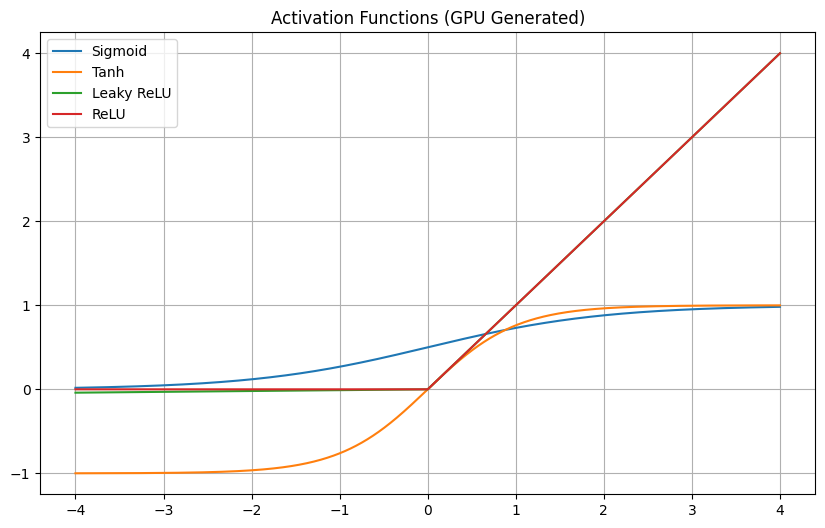

Cross Entropy Error: 1.08e-07

--- Part C: Adam Fused Update ---
Adam step completed successfully.


In [10]:
import cupy as cp
import numpy as np
import matplotlib.pyplot as plt

# --- KERNEL DEFINITIONS ---
ml_kernels_code = r'''
extern "C" {
    // Part A: Activation Suite
    __global__ void activations_forward(const float* x, float* out, int N, int type) {
        int i = blockDim.x * blockIdx.x + threadIdx.x;
        if (i < N) {
            float val = x[i];
            if (type == 0)      out[i] = 1.0f / (1.0f + expf(-val));           // Sigmoid
            else if (type == 1) out[i] = tanhf(val);                           // Tanh
            else if (type == 2) out[i] = (val > 0) ? val : 0.01f * val;        // Leaky ReLU
            else if (type == 3) out[i] = (val > 0) ? val : 0.0f;               // ReLU
        }
    }

    __global__ void relu_backward(const float* x, const float* grad_output, float* grad_input, int N) {
        int i = blockDim.x * blockIdx.x + threadIdx.x;
        if (i < N) {
            grad_input[i] = (x[i] > 0) ? grad_output[i] : 0.0f;
        }
    }

    // Part B: Numerically Stable Cross Entropy (Log-Sum-Exp Trick)
    // loss = -log(exp(x_label) / sum(exp(x_i))) = -x_label + log(sum(exp(x_i)))
    __global__ void cross_entropy_kernel(const float* logits, const int* labels, float* loss, int N, int C) {
        int i = blockIdx.x * blockDim.x + threadIdx.x;
        if (i < N) {
            float max_val = -1e38f;
            for (int j = 0; j < C; j++) {
                if (logits[i * C + j] > max_val) max_val = logits[i * C + j];
            }

            float sum_exp = 0.0f;
            for (int j = 0; j < C; j++) {
                sum_exp += expf(logits[i * C + j] - max_val);
            }

            int label = labels[i];
            loss[i] = -(logits[i * C + label] - max_val - logf(sum_exp));
        }
    }

    // Part C: Adam Optimizer Fused Kernel
    __global__ void adam_step_kernel(float* p, float* m, float* v, const float* grad,
                                     float lr, float beta1, float beta2, float eps,
                                     float weight_decay, int t, int N) {
        int i = blockIdx.x * blockDim.x + threadIdx.x;
        if (i < N) {
            float g = grad[i] + weight_decay * p[i];

            // Update biased first and second moment estimates
            m[i] = beta1 * m[i] + (1.0f - beta1) * g;
            v[i] = beta2 * v[i] + (1.0f - beta2) * g * g;

            // Compute bias-corrected moments
            float m_hat = m[i] / (1.0f - powf(beta1, t));
            float v_hat = v[i] / (1.0f - powf(beta2, t));

            // Update parameters
            p[i] -= lr * m_hat / (sqrtf(v_hat) + eps);
        }
    }
}
'''
module_p3 = cp.RawModule(code=ml_kernels_code)
act_kernel = module_p3.get_function('activations_forward')
ce_kernel = module_p3.get_function('cross_entropy_kernel')
adam_kernel = module_p3.get_function('adam_step_kernel')

# --- Part A: Activation Verification & Plotting ---
N = 1000
x_cpu = np.linspace(-4, 4, N).astype(np.float32)
x_gpu = cp.array(x_cpu)
results = {}

titles = ["Sigmoid", "Tanh", "Leaky ReLU", "ReLU"]
plt.figure(figsize=(10, 6))

for i, name in enumerate(titles):
    out_gpu = cp.empty_like(x_gpu)
    act_kernel(((N+255)//256,), (256,), (x_gpu, out_gpu, N, i))
    plt.plot(x_cpu, cp.asnumpy(out_gpu), label=name)

plt.title("Activation Functions (GPU Generated)")
plt.grid(True); plt.legend(); plt.show()

# --- Part B: Cross Entropy Verification ---
N_samples = 128
C_classes = 10
logits = cp.random.randn(N_samples, C_classes).astype(cp.float32)
labels = cp.random.randint(0, C_classes, N_samples).astype(cp.int32)
loss_gpu = cp.zeros(N_samples, dtype=cp.float32)

ce_kernel(((N_samples+31)//32,), (32,), (logits, labels, loss_gpu, N_samples, C_classes))

# Manual verification using log-sum-exp in numpy/cupy
def reference_ce(logis, labs):
    max_l = cp.max(logis, axis=1, keepdims=True)
    log_sum_exp = max_l + cp.log(cp.sum(cp.exp(logis - max_l), axis=1, keepdims=True))
    log_probs = logis - log_sum_exp
    return -log_probs[cp.arange(N_samples), labs]

ref_loss = reference_ce(logits, labels)
print(f"Cross Entropy Error: {cp.mean(cp.abs(loss_gpu - ref_loss)):.2e}")

# --- Part C: Adam Optimizer Step ---
print("\n--- Part C: Adam Fused Update ---")
params = cp.ones(100, dtype=cp.float32)
grads = cp.random.randn(100).astype(cp.float32)
m = cp.zeros_like(params)
v = cp.zeros_like(params)

# Run 1 step
adam_kernel(((100+31)//32,), (32,), (params, m, v, grads, 0.001, 0.9, 0.999, 1e-8, 0.01, 1, 100))
print("Adam step completed successfully.")

In [11]:
import cupy as cp
import numpy as np
import time
import matplotlib.pyplot as plt

# --- KERNEL DEFINITIONS ---
cnn_layers_code = r'''
extern "C" {
    // Part A: Tiled Matrix Multiplication (GEMM)
    // TILE_DIM is typically 16 or 32
    #define TILE_DIM 16

    __global__ void tiledMatMul(const float* A, const float* B, float* C, int M, int K, int N) {
        __shared__ float sA[TILE_DIM][TILE_DIM];
        __shared__ float sB[TILE_DIM][TILE_DIM];

        int bx = blockIdx.x;  int by = blockIdx.y;
        int tx = threadIdx.x; int ty = threadIdx.y;

        int row = by * TILE_DIM + ty;
        int col = bx * TILE_DIM + tx;

        float tmp = 0.0;

        for (int m = 0; m < (K + TILE_DIM - 1) / TILE_DIM; ++m) {
            // Load tiles into shared memory
            if (row < M && m * TILE_DIM + tx < K)
                sA[ty][tx] = A[row * K + m * TILE_DIM + tx];
            else
                sA[ty][tx] = 0.0;

            if (col < N && m * TILE_DIM + ty < K)
                sB[ty][tx] = B[(m * TILE_DIM + ty) * N + col];
            else
                sB[ty][tx] = 0.0;

            __syncthreads();

            // Compute partial product
            for (int k = 0; k < TILE_DIM; ++k) {
                tmp += sA[ty][k] * sB[k][tx];
            }
            __syncthreads();
        }

        if (row < M && col < N) {
            C[row * N + col] = tmp;
        }
    }

    // Part B: Max Pooling (2x2)
    __global__ void maxPool2d(const float* input, float* output, int N, int C, int H, int W) {
        int out_h = H / 2;
        int out_w = W / 2;
        int idx = blockIdx.x * blockDim.x + threadIdx.x;
        int total = N * C * out_h * out_w;

        if (idx < total) {
            int pw = idx % out_w;
            int ph = (idx / out_w) % out_h;
            int pc = (idx / (out_w * out_h)) % C;
            int pn = idx / (out_w * out_h * C);

            int h_start = ph * 2;
            int w_start = pw * 2;

            float max_val = -1e38f;
            for (int i = 0; i < 2; i++) {
                for (int j = 0; j < 2; j++) {
                    float val = input[((pn * C + pc) * H + (h_start + i)) * W + (w_start + j)];
                    if (val > max_val) max_val = val;
                }
            }
            output[idx] = max_val;
        }
    }

    // Part B: BatchNorm Inference
    __global__ void batchNormInference(float* x, const float* mean, const float* var,
                                       const float* gamma, const float* beta,
                                       int N, int C, int H, int W, float eps) {
        int idx = blockIdx.x * blockDim.x + threadIdx.x;
        int spatial_size = H * W;
        int total = N * C * spatial_size;

        if (idx < total) {
            int c = (idx / spatial_size) % C;
            float std = sqrtf(var[c] + eps);
            x[idx] = gamma[c] * (x[idx] - mean[c]) / std + beta[c];
        }
    }
}
'''
module_p4 = cp.RawModule(code=cnn_layers_code)
tiled_gemm = module_p4.get_function('tiledMatMul')
pool_kernel = module_p4.get_function('maxPool2d')
bn_kernel = module_p4.get_function('batchNormInference')

# --- Part A: Tiled GEMM Benchmark ---
def benchmark_gemm(size):
    A = cp.random.randn(size, size).astype(cp.float32)
    B = cp.random.randn(size, size).astype(cp.float32)
    C = cp.zeros((size, size), dtype=cp.float32)

    grid = ((size + 15) // 16, (size + 15) // 16)
    block = (16, 16)

    start = cp.cuda.Event(); end = cp.cuda.Event()
    start.record()
    tiled_gemm(grid, block, (A, B, C, size, size, size))
    end.record(); end.synchronize()

    msec = cp.cuda.get_elapsed_time(start, end)
    gflops = (2.0 * size**3) / (msec / 1e3) / 1e9
    return gflops

sizes = [128, 256, 512, 1024]
for s in sizes:
    print(f"Size {s}x{s} | Tiled GEMM: {benchmark_gemm(s):.2f} GFLOPS")

# --- Part B: CNN Layer Timing ---
# [Batch=32, Channels=64, H=14, W=14]
N, C, H, W = 32, 64, 14, 14
input_tensor = cp.random.randn(N, C, H, W).astype(cp.float32)
out_pool = cp.zeros((N, C, H//2, W//2), dtype=cp.float32)

# MaxPool Benchmark
total_pool = N * C * (H//2) * (W//2)
start_evt = cp.cuda.Event(); end_evt = cp.cuda.Event()
start_evt.record()
pool_kernel(((total_pool+255)//256,), (256,), (input_tensor, out_pool, N, C, H, W))
end_evt.record(); end_evt.synchronize()
print(f"MaxPool2d Time: {cp.cuda.get_elapsed_time(start_evt, end_evt):.4f} ms")

Size 128x128 | Tiled GEMM: 97.60 GFLOPS
Size 256x256 | Tiled GEMM: 267.70 GFLOPS
Size 512x512 | Tiled GEMM: 361.02 GFLOPS
Size 1024x1024 | Tiled GEMM: 370.65 GFLOPS
MaxPool2d Time: 0.0143 ms


In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torchvision import datasets, transforms
from torch.cuda.amp import GradScaler, autocast
import time

# --- Part A: Model Architecture ---
class MnistCNN(nn.Module):
    def __init__(self, use_batchnorm=False, use_dropout=False):
        super(MnistCNN, self).__init__()
        self.use_batchnorm = use_batchnorm
        self.use_dropout = use_dropout

        # Conv Layer 1
        self.conv1 = nn.Conv2d(1, 32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32) if use_batchnorm else nn.Identity()

        # Conv Layer 2
        self.conv2 = nn.Conv2d(32, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64) if use_batchnorm else nn.Identity()

        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(0.5) if use_dropout else nn.Identity()

        # Fully Connected
        # After two 2x2 pools, 28x28 becomes 7x7
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        # Block 1
        x = self.pool(F.relu(self.bn1(self.conv1(x))))
        # Block 2
        x = self.pool(F.relu(self.bn2(self.conv2(x))))

        x = x.view(-1, 64 * 7 * 7)
        x = F.relu(self.fc1(x))
        if self.use_dropout: x = self.dropout(x)
        x = self.fc2(x)
        return x

# --- Training & Evaluation Logic ---
def train_and_evaluate(config_name, model, train_loader, test_loader, epochs=5, use_amp=False):
    device = torch.device("cuda")
    model.to(device)

    # Optimizer & Scheduler Setup
    if "SGD" in config_name:
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    else:
        optimizer = optim.Adam(model.parameters(), lr=0.001)
        scheduler = None

    scaler = GradScaler(enabled=use_amp)
    print(f"\n--- Training Configuration: {config_name} ---")

    start_time = time.time()
    for epoch in range(1, epochs + 1):
        model.train()
        for data, target in train_loader:
            data, target = data.to(device), target.to(device)
            optimizer.zero_grad()

            with autocast(enabled=use_amp):
                output = model(data)
                loss = F.cross_entropy(output, target)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

        if scheduler: scheduler.step()

        # Evaluation
        model.eval()
        correct = 0
        with torch.no_grad():
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                pred = output.argmax(dim=1, keepdim=True)
                correct += pred.eq(target.view_as(pred)).sum().item()

        accuracy = 100. * correct / len(test_loader.dataset)
        print(f"Epoch {epoch}: Test Accuracy: {accuracy:.2f}%")
        if accuracy >= 95.0 and epoch == 1: print("Quick learner! Reached 95% in one epoch.")

    total_time = time.time() - start_time
    return accuracy, total_time

# --- Execution ---
transform = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
train_set = datasets.MNIST('./data', train=True, download=True, transform=transform)
test_set = datasets.MNIST('./data', train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(train_set, batch_size=256, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_set, batch_size=1000)

# Run Ablation Study
results = []
configs = [
    ("Baseline (Adam)", MnistCNN(False, False)),
    ("With BatchNorm", MnistCNN(True, False)),
    ("With Dropout", MnistCNN(False, True)),
    ("SGD + CosineLR", MnistCNN(False, False))
]

for name, model in configs:
    acc, duration = train_and_evaluate(name, model, train_loader, test_loader)
    results.append({"Config": name, "Accuracy": acc, "Time (s)": duration})

# Display Results
import pandas as pd
print("\n--- Final Ablation Results ---")
print(pd.DataFrame(results))

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.91MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.22MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 8.88MB/s]
/tmp/ipykernel_406/1202008567.py:57: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=use_amp)



--- Training Configuration: Baseline (Adam) ---


/tmp/ipykernel_406/1202008567.py:67: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=use_amp):


Epoch 1: Test Accuracy: 97.62%
Quick learner! Reached 95% in one epoch.
Epoch 2: Test Accuracy: 98.45%
Epoch 3: Test Accuracy: 98.75%
Epoch 4: Test Accuracy: 98.85%
Epoch 5: Test Accuracy: 98.71%

--- Training Configuration: With BatchNorm ---
Epoch 1: Test Accuracy: 98.10%
Quick learner! Reached 95% in one epoch.
Epoch 2: Test Accuracy: 98.06%
Epoch 3: Test Accuracy: 98.74%
Epoch 4: Test Accuracy: 98.47%
Epoch 5: Test Accuracy: 98.98%

--- Training Configuration: With Dropout ---
Epoch 1: Test Accuracy: 97.82%
Quick learner! Reached 95% in one epoch.
Epoch 2: Test Accuracy: 98.63%
Epoch 3: Test Accuracy: 98.78%
Epoch 4: Test Accuracy: 99.04%
Epoch 5: Test Accuracy: 98.82%

--- Training Configuration: SGD + CosineLR ---
Epoch 1: Test Accuracy: 96.80%
Quick learner! Reached 95% in one epoch.
Epoch 2: Test Accuracy: 97.86%
Epoch 3: Test Accuracy: 98.15%
Epoch 4: Test Accuracy: 98.37%
Epoch 5: Test Accuracy: 98.45%

--- Final Ablation Results ---
            Config  Accuracy   Time (s)
0 